# Machine Learning Model Development

In this notebook, machine learning models are developed to predict parking demand level using the cleaned and aggregated parking dataset. The target variable is `demand_level`, which classifies parking demand as low, medium, or high.

The modelling workflow includes:
- loading the processed dataset
- preparing features and target variables
- encoding categorical variables
- splitting the dataset into training and testing sets
- training baseline and advanced models
- evaluating model performance

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [80]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [81]:
df = pd.read_csv("../data/processed/cleaned_demand_data.csv")
df.head()

,zone_number,status_day,status_hour,is_weekend,average_occupancy,demand_level
0,7010.0,Friday,1,False,0.0,Low
1,7010.0,Thursday,21,False,1.0,High
2,7010.0,Thursday,22,False,1.0,High
3,7010.0,Thursday,23,False,1.0,High
4,7010.0,Wednesday,9,False,0.0,Low


In [82]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1602 entries, 0 to 1601
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   zone_number        1602 non-null   float64
 1   status_day         1602 non-null   str    
 2   status_hour        1602 non-null   int64  
 3   is_weekend         1602 non-null   bool   
 4   average_occupancy  1602 non-null   float64
 5   demand_level       1602 non-null   str    
dtypes: bool(1), float64(2), int64(1), str(2)
memory usage: 64.3 KB
None

Missing values:
zone_number          0
status_day           0
status_hour          0
is_weekend           0
average_occupancy    0
demand_level         0
dtype: int64


## Problem Definition

The aim is to predict the parking demand category (`demand_level`) using time-based and zone-based features.

### Input features
- `zone_number`
- `status_hour`
- `status_day`
- `is_weekend`

### Target
- `demand_level`

In [83]:
X = df[["zone_number", "status_hour", "status_day", "is_weekend"]]
y = df["demand_level"]

print("Feature sample:")
display(X.head())

print("Target sample:")
display(y.head())

Feature sample:


,zone_number,status_hour,status_day,is_weekend
0,7010.0,1,Friday,False
1,7010.0,21,Thursday,False
2,7010.0,22,Thursday,False
3,7010.0,23,Thursday,False
4,7010.0,9,Wednesday,False


Target sample:


0     Low
1    High
2    High
3    High
4     Low
Name: demand_level, dtype: str

## Train-Test Split

The dataset is split into training and testing sets so that the models can be evaluated on unseen data.

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1281, 4)
Testing set size: (321, 4)


## Preprocessing

The dataset contains both numerical and categorical features.  
To prepare it for machine learning:

- numerical features are passed through with simple imputation if needed
- categorical features are one-hot encoded

In [85]:
numeric_features = ["zone_number", "status_hour"]
categorical_features = ["status_day", "is_weekend"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Model 1: Logistic Regression

Logistic Regression is used as the baseline model because it is simple, interpretable, and commonly used for classification tasks.

In [86]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [87]:
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_logistic), 4))
print("Logistic Regression Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred_logistic), 4))
print("Logistic Regression Macro F1:", round(f1_score(y_test, y_pred_logistic, average="macro"), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.3146
Logistic Regression Balanced Accuracy: 0.4093
Logistic Regression Macro F1: 0.3138

Classification Report:
              precision    recall  f1-score   support

        High       0.51      0.32      0.39       131
         Low       0.57      0.23      0.33       156
      Medium       0.13      0.68      0.22        34

    accuracy                           0.31       321
   macro avg       0.40      0.41      0.31       321
weighted avg       0.50      0.31      0.34       321



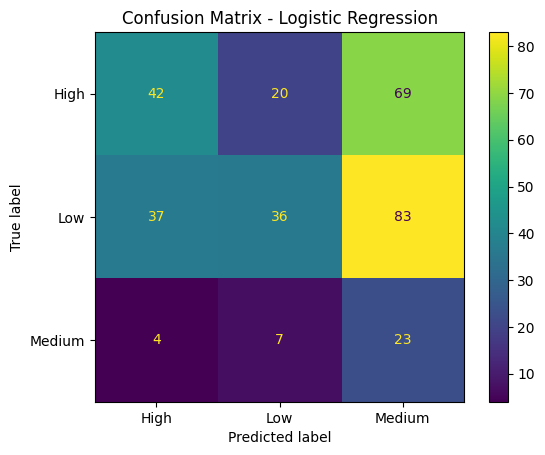

In [88]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic, labels=logistic_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=logistic_model.classes_)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Interpretation

The Logistic Regression model provides a baseline measure of classification performance. Its results indicate how well parking demand can be predicted using only the selected temporal and spatial features.

## Model 2: Random Forest

Random Forest is used as a more flexible model because it can capture non-linear patterns and interactions between features more effectively than Logistic Regression.

In [89]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [90]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Random Forest Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_pred_rf), 4))
print("Random Forest Macro F1:", round(f1_score(y_test, y_pred_rf, average="macro"), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.514
Random Forest Balanced Accuracy: 0.419
Random Forest Macro F1: 0.419

Classification Report:
              precision    recall  f1-score   support

        High       0.54      0.53      0.53       131
         Low       0.58      0.58      0.58       156
      Medium       0.13      0.15      0.14        34

    accuracy                           0.51       321
   macro avg       0.42      0.42      0.42       321
weighted avg       0.52      0.51      0.52       321



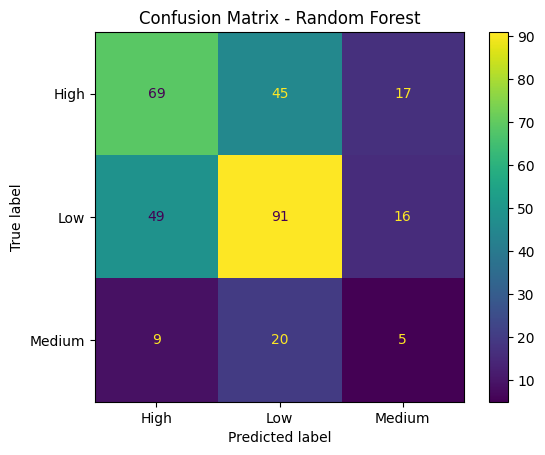

In [91]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=random_forest_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=random_forest_model.classes_)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Interpretation

The Random Forest model is expected to perform better than the baseline if the relationship between features and demand level is non-linear. Comparing both models helps determine whether the additional complexity improves predictive performance.

## Model Comparison

In [92]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf),
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred_logistic),
        balanced_accuracy_score(y_test, y_pred_rf),
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_logistic, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro"),
    ],
})

display(comparison_df.round(4))

,Model,Accuracy,Balanced Accuracy,Macro F1
0,Logistic Regression,0.3146,0.4093,0.3138
1,Random Forest,0.5140,0.4190,0.4190


<Figure size 900x500 with 0 Axes>

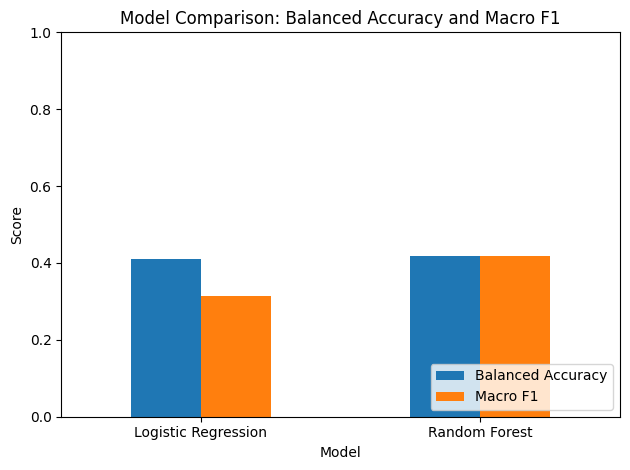

In [93]:
plot_df = comparison_df.set_index("Model")[["Balanced Accuracy", "Macro F1"]]

plt.figure(figsize=(9, 5))
plot_df.plot(kind="bar", ylim=(0, 1), rot=0)
plt.title("Model Comparison: Balanced Accuracy and Macro F1")
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Interpretation

This comparison highlights the relative performance of the baseline and advanced models. The better-performing model can be selected for the next stage of the project, such as prototype development or further optimisation.

## Robustness Check (5-Fold Cross-Validation)

To verify that test-set performance is not due to a single split, the selected model is validated using stratified 5-fold cross-validation on the full dataset.

The key metrics reported are:
- Accuracy
- Balanced Accuracy
- Macro F1

In [94]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_validate(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
    },
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy", "Macro F1"],
    "Mean": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_balanced_accuracy"].mean(),
        cv_scores["test_macro_f1"].mean(),
    ],
    "Std": [
        cv_scores["test_accuracy"].std(),
        cv_scores["test_balanced_accuracy"].std(),
        cv_scores["test_macro_f1"].std(),
    ],
})

display(cv_summary.round(4))

,Metric,Mean,Std
0,Accuracy,0.5068,0.0215
1,Balanced Accuracy,0.4344,0.0204
2,Macro F1,0.4303,0.0192


## Class Balance Check

Since the EDA showed that the demand classes are not evenly distributed, it is useful to confirm the class distribution before interpreting model performance.

In [95]:
class_counts = df["demand_level"].value_counts()
class_ratio = (class_counts / class_counts.sum() * 100).round(2)

print("Class counts:")
print(class_counts)
print("\nClass percentages (%):")
print(class_ratio)

Class counts:
demand_level
Low       781
High      652
Medium    169
Name: count, dtype: int64

Class percentages (%):
demand_level
Low       48.75
High      40.70
Medium    10.55
Name: count, dtype: float64


### Interpretation

The class distribution should be considered when evaluating the models. If one class appears much less frequently than the others, model performance may be less reliable for that class.

## Example Prediction

In [96]:
sample_input = pd.DataFrame({
    "zone_number": [7303],
    "status_hour": [10],
    "status_day": ["Monday"],
    "is_weekend": [False]
})

logistic_prediction = logistic_model.predict(sample_input)[0]
rf_prediction = random_forest_model.predict(sample_input)[0]

print("Sample input:")
display(sample_input)

print("Logistic Regression Prediction:", logistic_prediction)
print("Random Forest Prediction:", rf_prediction)

Sample input:


,zone_number,status_hour,status_day,is_weekend
0,7303,10,Monday,False


Logistic Regression Prediction: Medium
Random Forest Prediction: Low


### Interpretation

This example demonstrates how the trained model can be used to predict parking demand for a specific zone and time. Such predictions could later support a proof-of-concept system for smarter parking management.

## Conclusion

This notebook developed and compared two classification approaches for parking demand prediction using temporal and zone-based features.

- Logistic Regression served as a transparent baseline.
- A tuned Random Forest delivered stronger overall performance, especially on balanced metrics.
- Macro F1 and Balanced Accuracy were used alongside Accuracy to better reflect class imbalance.
- A 5-fold stratified cross-validation check showed that the selected model is reasonably stable across different data splits.

Overall, the Random Forest pipeline is the better candidate for deployment in a proof-of-concept parking demand support tool. Future improvements can focus on lifting performance for the minority class (`Medium`) through feature enrichment and threshold-sensitive optimisation.